In [1]:
import pandas as pd

def smooth_features(features, window_size=6):
    """
    Applies a rolling mean to features to stabilize HMM states.
    window_size=6 represents a 30-second moving average (6 * 5s).
    """
    df = pd.DataFrame(features)
    # Use Gaussian or simple rolling mean to reduce flicker
    smoothed = df.rolling(window=window_size, min_periods=1, center=False).mean()
    return smoothed.values

In [22]:
import numpy as np
from scipy.signal import welch, hilbert, butter, filtfilt
from antropy import perm_entropy

# --- Pre-define PAC Filters ---
def butter_bandpass(lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

# Filter coefficients for 256 Hz sampling rate
b_theta, a_theta = butter_bandpass(4.0, 8.0, 256)
b_gamma, a_gamma = butter_bandpass(30.0, 40.0, 256)

def get_regional_state_features(epoch_data, sfreq=256):
    features = []
    eps = 1e-10
    
    # Isolate Hemispheres based on standard bipolar pairs
    # Left: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1
    LEFT_CH = [0, 1, 2, 3, 4, 5, 6, 7]
    # Right: FP2-F4, F4-C4, C4-P4, P4-O2, FP2-F8, F8-T8, T8-P8, P8-O2
    RIGHT_CH = [8, 9, 10, 11, 12, 13, 14, 15]

    for window in epoch_data:
        X_left = window[LEFT_CH, :]
        X_right = window[RIGHT_CH, :]

        # --- 1. Morphological (RMS & Line Length) ---
        rms_L = np.mean(np.sqrt(np.mean(X_left**2, axis=1)))
        rms_R = np.mean(np.sqrt(np.mean(X_right**2, axis=1)))

        ll_L = np.mean(np.sum(np.abs(np.diff(X_left, axis=1)), axis=1))
        ll_R = np.mean(np.sum(np.abs(np.diff(X_right, axis=1)), axis=1))

        # --- 2. Spectral Power (Theta/Alpha) ---
        freqs_L, psd_L = welch(X_left, sfreq, nperseg=sfreq * 2)
        th_mask = (freqs_L >= 4) & (freqs_L < 8)
        al_mask = (freqs_L >= 8) & (freqs_L < 13)
        
        theta_L = np.trapezoid(psd_L[:, th_mask], freqs_L[th_mask], axis=1).mean()
        alpha_L = np.trapezoid(psd_L[:, al_mask], freqs_L[al_mask], axis=1).mean()
        ta_ratio_L = theta_L / (alpha_L + eps)

        freqs_R, psd_R = welch(X_right, sfreq, nperseg=sfreq * 2)
        theta_R = np.trapezoid(psd_R[:, th_mask], freqs_R[th_mask], axis=1).mean()
        alpha_R = np.trapezoid(psd_R[:, al_mask], freqs_R[al_mask], axis=1).mean()
        ta_ratio_R = theta_R / (alpha_R + eps)

        # --- 3. Phase-Amplitude Coupling (PAC) ---
        # Left PAC
        theta_sig_L = filtfilt(b_theta, a_theta, X_left, axis=1)
        gamma_sig_L = filtfilt(b_gamma, a_gamma, X_left, axis=1)
        theta_phase_L = np.angle(hilbert(theta_sig_L, axis=1))
        gamma_amp_L = np.abs(hilbert(gamma_sig_L, axis=1))
        pac_scores_L = [np.abs(np.corrcoef(np.cos(theta_phase_L[i]), gamma_amp_L[i])[0, 1]) for i in range(X_left.shape[0])]
        pac_L = np.mean(pac_scores_L)

        # Right PAC
        theta_sig_R = filtfilt(b_theta, a_theta, X_right, axis=1)
        gamma_sig_R = filtfilt(b_gamma, a_gamma, X_right, axis=1)
        theta_phase_R = np.angle(hilbert(theta_sig_R, axis=1))
        gamma_amp_R = np.abs(hilbert(gamma_sig_R, axis=1))
        pac_scores_R = [np.abs(np.corrcoef(np.cos(theta_phase_R[i]), gamma_amp_R[i])[0, 1]) for i in range(X_right.shape[0])]
        pac_R = np.mean(pac_scores_R)

        # --- 4. Spatial Sync (Cross-Hemisphere PLV) ---
        # Measure how locked the left hemisphere is to the right hemisphere
        phases_L = np.angle(hilbert(X_left, axis=1))
        phases_R = np.angle(hilbert(X_right, axis=1))
        
        sync_scores = []
        for i in range(len(LEFT_CH)):
            phase_diff = phases_L[i] - phases_R[i]
            plv = np.abs(np.mean(np.exp(1j * phase_diff)))
            sync_scores.append(plv)
            
        avg_sync = np.nanmean(sync_scores)
        if not np.isfinite(avg_sync):
            avg_sync = 0.0

        # --- Compile Regional Features ---
        features.append([
            rms_L, rms_R, 
            ll_L, ll_R, 
            ta_ratio_L, ta_ratio_R, 
            pac_L, pac_R, 
            avg_sync
        ])

    return np.array(features)

In [23]:
import numpy as np
from scipy.signal import welch, hilbert, butter, filtfilt
from antropy import perm_entropy

# Left↔Right homologous bipolar pairs (0-based indices) based on EDF channel list
# Left (1–8) pairs with Right (9–16 / 13–16) as appropriate:
PAIRS_LR = [
    (0, 12),  # ch1  FP1-F7  ↔ ch13 FP2-F8
    (1, 13),  # ch2  F7-T7   ↔ ch14 F8-T8
    (2, 14),  # ch3  T7-P7   ↔ ch15 T8-P8
    (3, 15),  # ch4  P7-O1   ↔ ch16 P8-O2
    (4, 8),   # ch5  FP1-F3  ↔ ch9  FP2-F4
    (5, 9),   # ch6  F3-C3   ↔ ch10 F4-C4
    (6, 10),  # ch7  C3-P3   ↔ ch11 C4-P4
    (7, 11),  # ch8  P3-O1   ↔ ch12 P4-O2
]

# --- Pre-define PAC Filters ---
def butter_bandpass(lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

# Filter coefficients for 256 Hz sampling rate
b_theta, a_theta = butter_bandpass(4.0, 8.0, 256)
b_gamma, a_gamma = butter_bandpass(30.0, 40.0, 256)


def get_advanced_state_features(epoch_data, sfreq=256):
    features = []
    eps = 1e-10
    PRIMARY_CH = list(range(18))  # ch1..ch18
    
    """
    Transforms 5-second EEG windows into a 6D state-space coordinate:
    1. Theta/Alpha Ratio
    2. Permutation Entropy
    3. Line Length (Spikiness)
    4. RMS Amplitude (Power)
    5. Hemispheric Synchronization (Phase-Locking Value)
    6. Phase-Amplitude Coupling (Theta-Gamma)
    """

    for window in epoch_data:
        X = window[PRIMARY_CH, :]

        # --- 1. Spectral Power (Theta/Alpha) ---
        freqs, psd = welch(X, sfreq, nperseg=sfreq * 2)
        th_mask = (freqs >= 4) & (freqs < 8)
        al_mask = (freqs >= 8) & (freqs < 13)
        theta = np.trapezoid(psd[:, th_mask], freqs[th_mask], axis=1).mean()
        alpha = np.trapezoid(psd[:, al_mask], freqs[al_mask], axis=1).mean()
        ta_ratio = theta / (alpha + eps)

        # --- 2. Complexity ---
        complexity = np.mean([perm_entropy(ch, order=4, delay=1, normalize=True) for ch in X])

        # --- 3. Spatial Sync (Phase-Locking Value) ---
        # Get instantaneous phase for all channels at once
        phases = np.angle(hilbert(X, axis=1))
        
        sync_scores = []
        for li, ri in PAIRS_LR:
            # Calculate phase difference
            phase_diff = phases[li] - phases[ri]
            # Calculate PLV for this pair (magnitude of the mean complex phase vector)
            plv = np.abs(np.mean(np.exp(1j * phase_diff)))
            sync_scores.append(plv)
            
        avg_sync = np.nanmean(sync_scores)
        if not np.isfinite(avg_sync):
            avg_sync = 0.0

        # --- 4. Morphological ---
        line_length = np.mean(np.sum(np.abs(np.diff(X, axis=1)), axis=1))
        rms = np.mean(np.sqrt(np.mean(X**2, axis=1)))

        # --- 5. Phase-Amplitude Coupling (Theta-Gamma) ---
        # Fast vectorized filtering across all primary channels
        theta_sig = filtfilt(b_theta, a_theta, X, axis=1)
        gamma_sig = filtfilt(b_gamma, a_gamma, X, axis=1)
        
        # Hilbert transform to get phase and amplitude
        theta_phase = np.angle(hilbert(theta_sig, axis=1))
        gamma_amp = np.abs(hilbert(gamma_sig, axis=1))
        
        # Calculate coupling for each channel, then average
        pac_scores = [np.abs(np.corrcoef(np.cos(theta_phase[i]), gamma_amp[i])[0, 1]) for i in range(X.shape[0])]
        avg_pac = np.mean(pac_scores)

        # --- Compile Features ---
        features.append([ta_ratio, complexity, line_length, rms, avg_sync, avg_pac])

    return np.array(features)

## Epoching of the Patient 1 data  
Split the edfs into 5 minute chunks. Each edf is 1-hour long. We choose 01.edf for the baseline data and 03.edf for the data with seizure.

In [24]:
import mne
import numpy as np

# Patient 1 (chb04) EDF list from your summary
train_files = [
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_01.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_02.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_03.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_04.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_05.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_06.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_07.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_08.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_09.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_10.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_11.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_12.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_13.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_14.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_15.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_16.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_17.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_18.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_19.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_21.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_22.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_23.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_24.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_25.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_26.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_27.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_28.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_29.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_30.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_31.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_32.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_33.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_34.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_35.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_36.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_37.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_38.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_39.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_40.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_41.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_42.edf"},
    {"path": "chb-mit-scalp-eeg-database-1.0.0/chb04/chb04_43.edf"},
]


all_features = []
lengths = []

for i, f_info in enumerate(train_files, start=1):
    path = f_info["path"]

    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    raw.rename_channels(lambda x: x.strip("."))

    # Safety: ensure we really have 256 Hz (resample if not)
    if raw.info["sfreq"] != 256:
        raw.resample(256, npad="auto", verbose=False)

    raw.filter(1.0, 40.0, fir_design="firwin", verbose=False)
    raw.notch_filter(freqs=[60], verbose=False)

    # 5s fixed-length epochs
    epochs = mne.make_fixed_length_epochs(raw, duration=5.0, preload=True, verbose=False)
    data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

    feats = get_regional_state_features(data, sfreq=int(raw.info["sfreq"]))
    all_features.append(feats)
    lengths.append(len(feats))

    if i % 5 == 0 or i == len(train_files):
        print(f"Loaded {i}/{len(train_files)} files; last epochs={len(feats)}")

print("Loading complete.")


/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.

Loaded 5/42 files; last epochs=1907


/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.

Loaded 10/42 files; last epochs=2880


/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.

...

Loaded 35/42 files; last epochs=2880


/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.

Loaded 40/42 files; last epochs=2880


/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/var/folders/zf/_1h962cx0q3dj615fqjpj7bw0000gn/T/ipykernel_85805/2733474965.py:57: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Loaded 42/42 files; last epochs=2880
Loading complete.


In [25]:
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm

# 1. Scale and Smooth each file INDIVIDUALLY
# This prevents the 'loudness' of File 01 from being compared to File 03
processed_all_features = []

for f_features in all_features:
    # A. Scale this specific file to its own mean/std
    scaler_local = StandardScaler()
    feat_local_scaled = scaler_local.fit_transform(f_features)
    
    # B. Smooth the normalized data
    # (Using your existing smooth_features function)
    feat_local_smoothed = smooth_features(feat_local_scaled, window_size=6)
    
    processed_all_features.append(feat_local_smoothed)

# 2. Re-combine (Stack) and PCA
# We don't need another StandardScaler here because they are already Z-scored
feat_stack_final = np.vstack(processed_all_features)

#pca = PCA(n_components=3)
#obs_for_hmm_final = pca.fit_transform(feat_stack_final)

obs_for_hmm_final = feat_stack_final

# 3. Re-train HMM
model = hmm.GaussianHMM(
    n_components=3, 
    covariance_type="diag", 
    n_iter=2000, 
    random_state=42
)
model.fit(obs_for_hmm_final, lengths =lengths)

print("Properly Scaled & Smoothed HMM Training Complete.")

Properly Scaled & Smoothed HMM Training Complete.


Transition Probability Matrix:
         State 0  State 1  State 2
State 0   0.9236   0.0364   0.0399
State 1   0.0581   0.9418   0.0001
State 2   0.0489   0.0002   0.9509


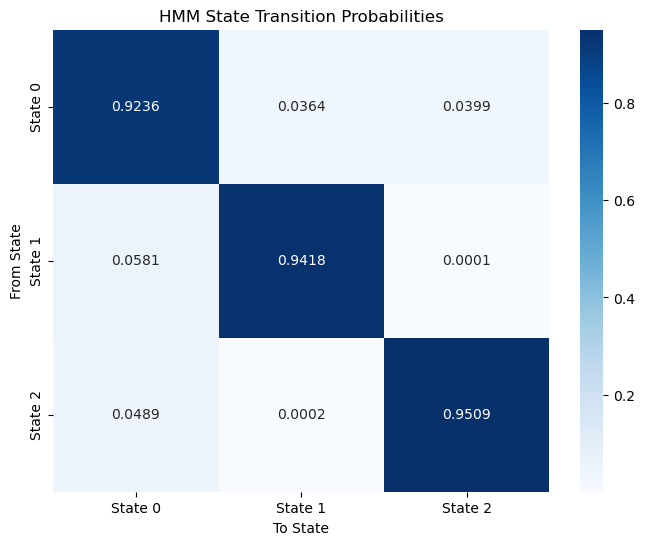

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# The matrix itself
trans_matrix = model.transmat_

# Create a clean DataFrame for viewing
state_labels = ["State 0", "State 1", "State 2"]
df_trans = pd.DataFrame(trans_matrix, columns=state_labels, index=state_labels)

print("Transition Probability Matrix:")
print(df_trans.round(4))

# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(df_trans, annot=True, cmap='Blues', fmt='.4f')
plt.title("HMM State Transition Probabilities")
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()

In [27]:
for i in range(model.n_components):
    print(f"State {i} means:")
    print(f"  Left RMS    : {model.means_[i, 0]:+.3f}")
    print(f"  Right RMS   : {model.means_[i, 1]:+.3f}")
    print(f"  Left LL     : {model.means_[i, 2]:+.3f}")
    print(f"  Right LL    : {model.means_[i, 3]:+.3f}")
    print(f"  Left TA     : {model.means_[i, 4]:+.3f}")
    print(f"  Right TA    : {model.means_[i, 5]:+.3f}")
    print(f"  Left PAC    : {model.means_[i, 6]:+.3f}")
    print(f"  Right PAC   : {model.means_[i, 7]:+.3f}")
    print(f"  Cross Sync  : {model.means_[i, 8]:+.3f}\n")


State 0 means:
  Left RMS    : -0.116
  Right RMS   : -0.118
  Left LL     : -0.152
  Right LL    : -0.165
  Left TA     : -0.055
  Right TA    : -0.036
  Left PAC    : -0.014
  Right PAC   : -0.020
  Cross Sync  : -0.003

State 1 means:
  Left RMS    : +0.983
  Right RMS   : +0.968
  Left LL     : +0.963
  Right LL    : +0.958
  Left TA     : +0.743
  Right TA    : +0.699
  Left PAC    : -0.179
  Right PAC   : -0.183
  Cross Sync  : -0.071

State 2 means:
  Left RMS    : -0.618
  Right RMS   : -0.604
  Left LL     : -0.558
  Right LL    : -0.540
  Left TA     : -0.507
  Right TA    : -0.496
  Left PAC    : +0.156
  Right PAC   : +0.166
  Cross Sync  : +0.058



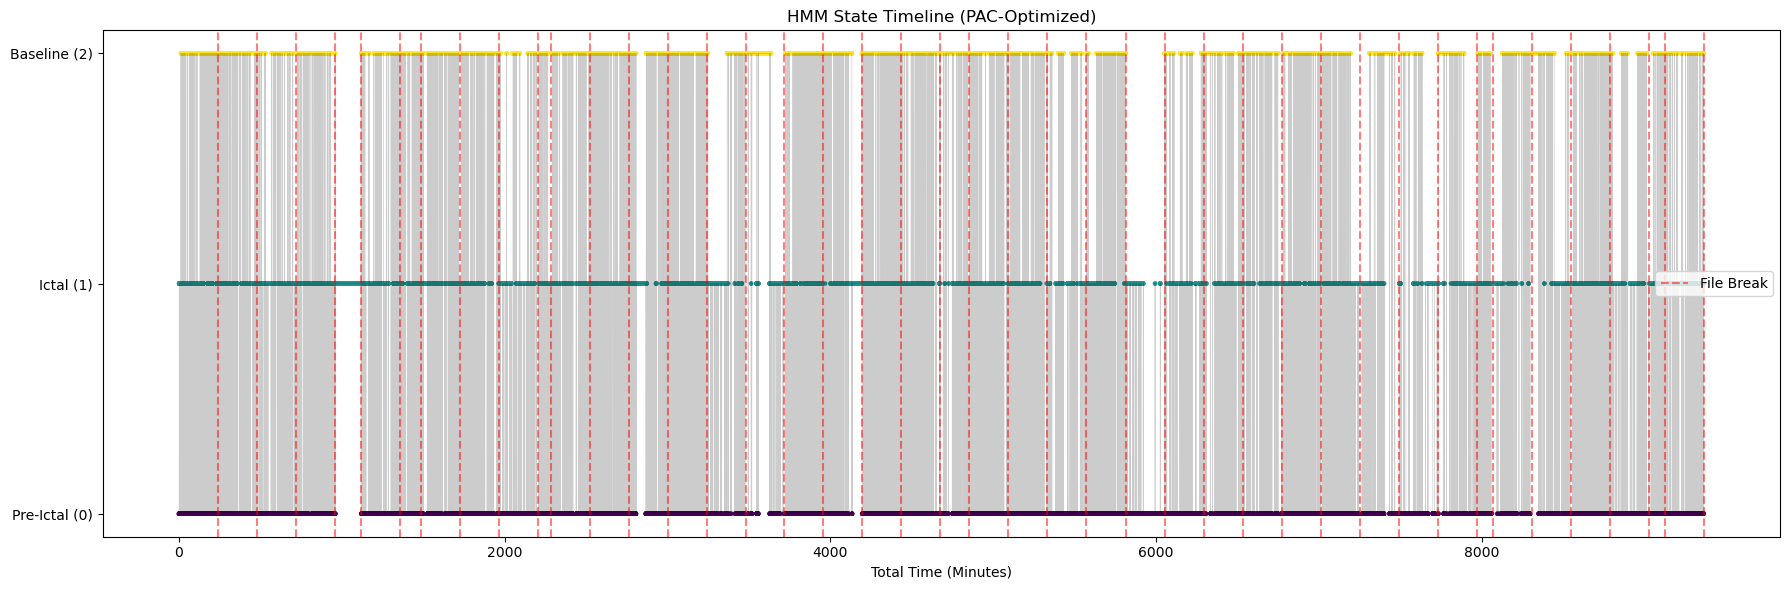

In [28]:
# === Predict hidden states (respect file boundaries) ===
hidden_states = model.predict(obs_for_hmm_final, lengths=lengths)

# === Plot timeline ===
WINDOW_SEC = 5.0  # explicit for safety
time_axis = np.arange(len(hidden_states)) * WINDOW_SEC / 60.0  # minutes

plt.figure(figsize=(18, 6))
plt.scatter(time_axis, hidden_states, c=hidden_states, cmap='viridis', s=5, alpha=0.5)
plt.plot(time_axis, hidden_states, color='black', linewidth=0.5, alpha=0.2)

# === Mark file boundaries ===
current_min = 0.0
for k, length in enumerate(lengths):
    current_min += (length * WINDOW_SEC / 60.0)
    plt.axvline(
        x=current_min,
        color='red',
        linestyle='--',
        alpha=0.5,
        label='File Break' if k == 0 else None
    )
plt.legend()

# === Derive state labels from feature-space means ===
# Feature order:
# [0] TA_ratio, [1] PermEntropy, [2] LineLength, 
# [3] RMS, [4] Avg Sync, [5] Avg PAC

# === 9D Regional State Labeling ===
# [0] L_RMS, [1] R_RMS, [2] L_LL, [3] R_LL, [4] L_TA, [5] R_TA, [6] L_PAC, [7] R_PAC, [8] Sync
IDX_RMS_L = 0
IDX_RMS_R = 1

# Calculate total energy across both hemispheres for each state
total_rms = model.means_[:, IDX_RMS_L] + model.means_[:, IDX_RMS_R]

# 1. Ictal: Highest total energy
ictal_state = int(np.argmax(total_rms))

# 2. Baseline: Lowest total energy
baseline_state = int(np.argmin(total_rms))

# 3. Pre-Ictal: The middle state
preictal_state = [s for s in range(3) if s not in (ictal_state, baseline_state)][0]

label_map = {
    baseline_state: "Baseline",
    preictal_state: "Pre-Ictal",
    ictal_state: "Ictal"
}

yticklabels = [f"{label_map[s]} ({s})" for s in range(model.n_components)]
plt.yticks(range(model.n_components), yticklabels)

plt.xlabel("Total Time (Minutes)")
plt.title("HMM State Timeline (PAC-Optimized)")
plt.tight_layout()
plt.show()


In [29]:
import os
import numpy as np

WINDOW_SEC = 5.0  # keep consistent with epoch duration

# Expect these from ln[42]:
# - label_map: {state_id: "Baseline"/"Pre-Ictal"/"Ictal"}
# - hidden_states
# - lengths
# - train_files

current_idx = 0

print(f"{'Filename':<15} | {'State':<10} | {'Start (sec)':<12} | {'End (sec)':<12}")
print("-" * 60)

for i, length in enumerate(lengths):
    file_states = hidden_states[current_idx : current_idx + length]
    filename = os.path.basename(train_files[i]["path"])

    # indices where state changes (boundary starts at these indices)
    transitions = np.where(np.diff(file_states) != 0)[0] + 1
    endpoints = np.concatenate(([0], transitions, [length]))

    for j in range(len(endpoints) - 1):
        start_win = int(endpoints[j])
        end_win = int(endpoints[j + 1])
        state = int(file_states[start_win])

        start_sec = start_win * WINDOW_SEC
        end_sec = end_win * WINDOW_SEC

        state_label = label_map.get(state, f"State {state}")

        # Print only Pre-Ictal and Ictal segments
        if state_label in ("Pre-Ictal", "Ictal"):
            print(f"{filename:<15} | {state_label:<10} | {start_sec:<12.0f} | {end_sec:<12.0f}")

    current_idx += length

Filename        | State      | Start (sec)  | End (sec)   
------------------------------------------------------------
chb04_01.edf    | Pre-Ictal  | 0            | 55          
chb04_01.edf    | Ictal      | 55           | 220         
chb04_01.edf    | Pre-Ictal  | 220          | 255         
chb04_01.edf    | Ictal      | 255          | 360         
chb04_01.edf    | Pre-Ictal  | 360          | 450         
chb04_01.edf    | Ictal      | 450          | 475         
chb04_01.edf    | Pre-Ictal  | 475          | 725         
chb04_01.edf    | Pre-Ictal  | 745          | 880         
chb04_01.edf    | Ictal      | 880          | 890         
chb04_01.edf    | Pre-Ictal  | 890          | 985         
chb04_01.edf    | Pre-Ictal  | 1045         | 1105        
chb04_01.edf    | Pre-Ictal  | 1130         | 1275        
chb04_01.edf    | Pre-Ictal  | 1465         | 1480        
chb04_01.edf    | Ictal      | 1480         | 1500        
chb04_01.edf    | Pre-Ictal  | 1500         | 1520    

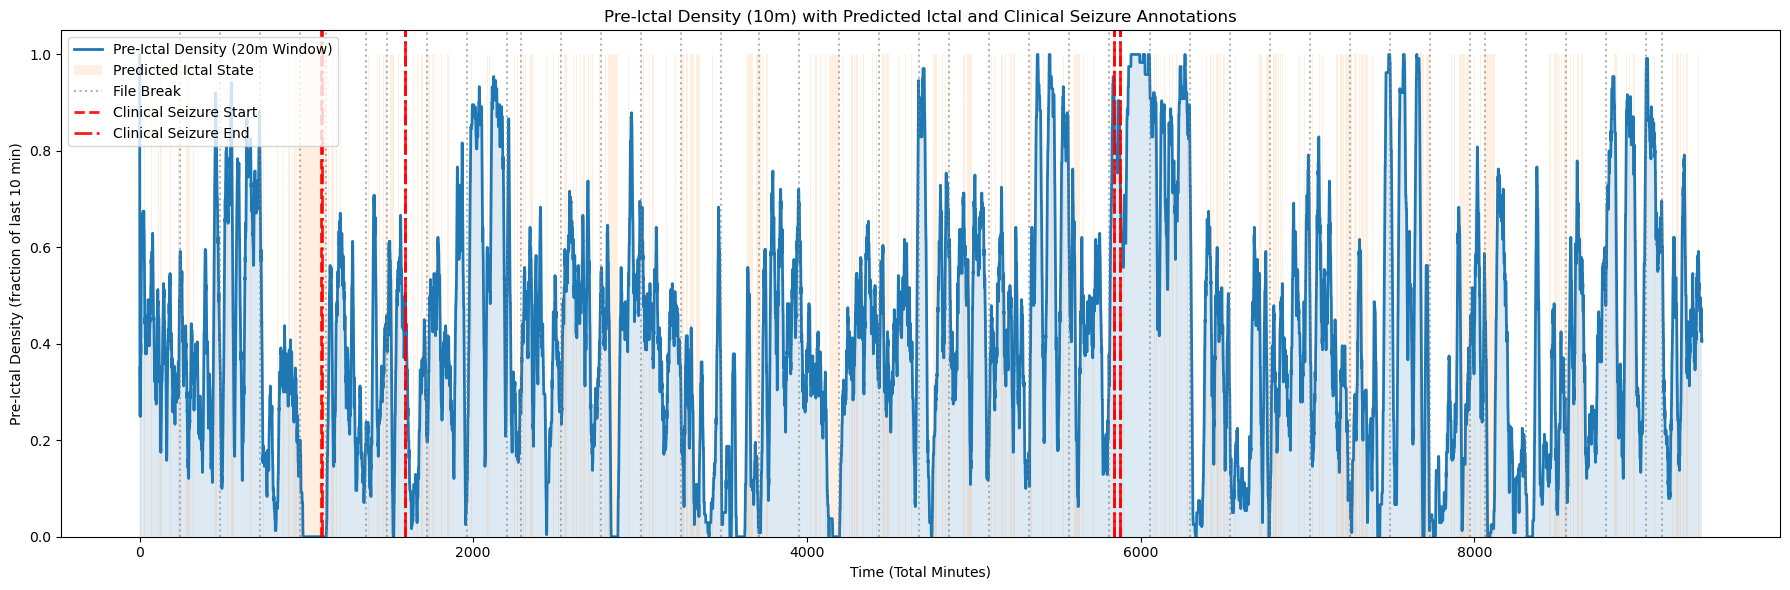

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os

WINDOW_SEC = 5.0
DENSITY_MIN = 20.0
W = int((DENSITY_MIN * 60.0) / WINDOW_SEC)  # 10 minutes -> 120 windows

# --- Identify which numeric states are Pre-Ictal and Ictal ---
pre_state = next(s for s, name in label_map.items() if name == "Pre-Ictal")
ictal_state = next(s for s, name in label_map.items() if name == "Ictal")

# --- Rolling pre-ictal density (causal) over last W windows ---
pre_indicator = (hidden_states == pre_state).astype(float)
kernel = np.ones(W, dtype=float)
pre_density = np.convolve(pre_indicator, kernel, mode="full")[:len(pre_indicator)] / W
# fix startup so early points are averaged over fewer samples (optional but nicer)
for i in range(min(W-1, len(pre_density))):
    pre_density[i] *= W / (i+1)

# --- Build a global time axis in minutes ---
t_min = (np.arange(len(hidden_states)) * WINDOW_SEC) / 60.0

# --- Build file offsets (start time in windows/minutes for each file in the concatenated series) ---
file_start_win = np.cumsum([0] + lengths[:-1])
file_start_min = file_start_win * WINDOW_SEC / 60.0

# --- Clinical seizure annotations you provided (seconds-from-file-start) ---
# Only for the seizure files here; extend as needed.
clinical = {
    "chb04_05.edf": [(7804, 7853)],
    "chb04_08.edf": [(6446, 6557)],
    "chb04_28.edf": [(1679, 1781), (3782, 3898)],
}

# --- Plot ---
plt.figure(figsize=(18, 6))

# Pre-ictal density line + light fill
plt.plot(t_min, pre_density, linewidth=2, label=f"Pre-Ictal Density ({int(DENSITY_MIN)}m Window)")
plt.fill_between(t_min, 0, pre_density, alpha=0.15)

# Shade predicted ictal windows
ictal_mask = (hidden_states == ictal_state)
plt.fill_between(t_min, 0, 1, where=ictal_mask, alpha=0.12, label="Predicted Ictal State")

# File breaks
for k, startm in enumerate(file_start_min[1:]):  # skip first at 0
    plt.axvline(x=startm, color="gray", linestyle=":", alpha=0.6, label="File Break" if k == 0 else None)

# Clinical seizure start/end markers
# Convert per-file seconds to global minutes using file offset
seen_label_start = False
seen_label_end = False

for i, f in enumerate(train_files):
    fname = os.path.basename(f["path"])
    if fname not in clinical:
        continue
    base_min = file_start_min[i]
    for (s0, s1) in clinical[fname]:
        x0 = base_min + (s0 / 60.0)
        x1 = base_min + (s1 / 60.0)
        plt.axvline(x=x0, color="red", linestyle="--", linewidth=2, alpha=0.9,
                    label="Clinical Seizure Start" if not seen_label_start else None)
        plt.axvline(x=x1, color="red", linestyle="-.", linewidth=2, alpha=0.9,
                    label="Clinical Seizure End" if not seen_label_end else None)
        seen_label_start = True
        seen_label_end = True

plt.ylim(0, 1.05)
plt.xlabel("Time (Total Minutes)")
plt.ylabel("Pre-Ictal Density (fraction of last 10 min)")
plt.title("Pre-Ictal Density (10m) with Predicted Ictal and Clinical Seizure Annotations")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


Running 1000 permutations for statistical significance...


100%|████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 373.25it/s]


Threshold Analysis Results (File-Aware):
 Threshold (m)  Seizure Probability (x%)  P-Value  Significant (p<0.05)
          0.00                  1.660797    1.000                 False
          0.05                  1.691825    1.000                 False
          0.10                  1.713634    1.000                 False
          0.15                  1.776083    1.000                 False
          0.20                  1.897869    1.000                 False
          0.25                  2.018848    1.000                 False
          0.30                  2.170300    1.000                 False
          0.35                  2.383561    1.000                 False
          0.40                  2.613928    0.864                 False
          0.45                  2.865992    0.136                 False
          0.50                  3.024810    0.032                  True
          0.55                  3.035612    0.031                  True
          0.60        

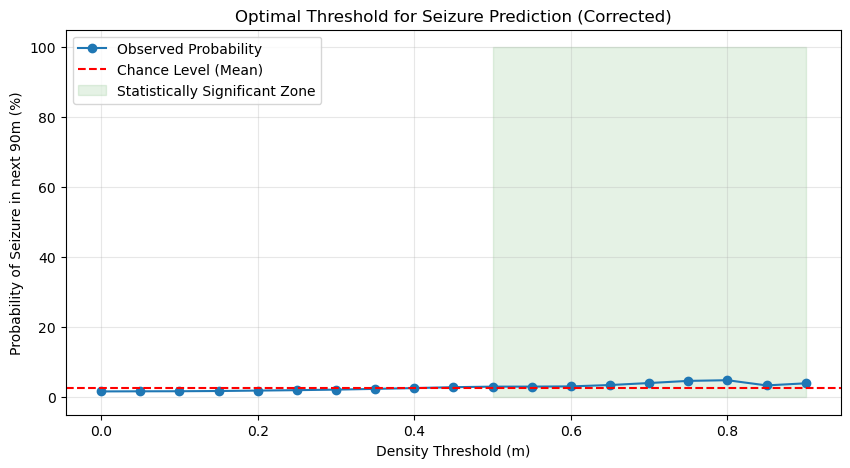

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# --- 1. Define the Prediction Target (Respecting File Boundaries) ---
PREDICTION_WINDOW_MIN = 90.0
y_true = np.zeros(len(t_min))
current_idx = 0

for i, length in enumerate(lengths):
    fname = os.path.basename(train_files[i]["path"])
    # Create a time axis for JUST this file
    file_t_min = (np.arange(length) * WINDOW_SEC) / 60.0
    file_y = np.zeros(length)
    
    if fname in clinical:
        for (s0, s1) in clinical[fname]:
            # Mark windows where a seizure starts within the next 90 mins IN THIS FILE
            start_min = s0 / 60.0
            mask = (file_t_min <= start_min) & (file_t_min >= start_min - PREDICTION_WINDOW_MIN)
            file_y[mask] = 1
    
    # Place this file's ground truth into the global array
    y_true[current_idx : current_idx + length] = file_y
    current_idx += length

# --- 2. Calculate Probabilities for different Thresholds (m) ---
thresholds = np.linspace(0, 0.9, 19) 
observed_probs = []

for m in thresholds:
    alarm_mask = pre_density > m
    if np.any(alarm_mask):
        # Accuracy: How often was our alarm followed by a seizure?
        prob = np.mean(y_true[alarm_mask])
        observed_probs.append(prob)
    else:
        observed_probs.append(0.0)

# --- 3. Statistical Significance (Monte Carlo / Surrogate Test) ---
# We shuffle WITHIN the constraints of the data to see if we beat chance
n_permutations = 1000
surrogate_max_probs = []

print(f"Running {n_permutations} permutations for statistical significance...")
for _ in tqdm(range(n_permutations)):
    # Randomly shuffle the TRUE labels to create a "fake" patient history
    y_surrogate = np.random.permutation(y_true)

    # Calculate the max probability achieved by chance for ANY threshold
    chance_probs = [np.mean(y_surrogate[pre_density > m]) if np.any(pre_density > m) else 0 for m in thresholds]
    surrogate_max_probs.append(np.max(chance_probs))

# Calculate p-value for each threshold
p_values = []
for i, m in enumerate(thresholds):
    better_than_us = np.sum(np.array(surrogate_max_probs) >= observed_probs[i])
    p_values.append(better_than_us / n_permutations)

# --- 4. Results Table & Plotting ---
results_df = pd.DataFrame({
    "Threshold (m)": thresholds,
    "Seizure Probability (x%)": np.array(observed_probs) * 100,
    "P-Value": p_values,
    "Significant (p<0.05)": np.array(p_values) < 0.05
})

print("\nThreshold Analysis Results (File-Aware):")
print(results_df.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(thresholds, np.array(observed_probs)*100, marker='o', label="Observed Probability")
plt.axhline(y=np.mean(surrogate_max_probs)*100, color='r', linestyle='--', label="Chance Level (Mean)")
plt.fill_between(thresholds, 0, 100, where=results_df["Significant (p<0.05)"], 
                 color='green', alpha=0.1, label="Statistically Significant Zone")

plt.xlabel("Density Threshold (m)")
plt.ylabel("Probability of Seizure in next 90m (%)")
plt.title("Optimal Threshold for Seizure Prediction (Corrected)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
import numpy as np
import os

# --- Clinical Evaluation Parameters ---
SPH_SEC = 5 * 60          # 5 minutes minimum warning
SOP_SEC = 85 * 60         # 85 minutes occurrence period 
REFRACTORY_SEC = 90 * 60  # 90 minutes silence after an alarm is triggered

# 1. Build a list of exact clinical seizure start times in the global timeline
global_seizure_onsets = []
file_start_sec = np.cumsum([0] + lengths[:-1]) * WINDOW_SEC

for i, f in enumerate(train_files):
    fname = os.path.basename(f["path"])
    if fname in clinical:
        base_sec = file_start_sec[i]
        for (s0, s1) in clinical[fname]:
            global_seizure_onsets.append(base_sec + s0)

# 2. Setup Evaluation Loop
total_hours = len(hidden_states) * WINDOW_SEC / 3600.0
total_days = total_hours / 24.0

print(f"Total Recording Time: {total_hours:.2f} hours ({total_days:.2f} days)")
print(f"Total Clinical Seizures: {len(global_seizure_onsets)}")
print(f"Parameters -> SPH: {SPH_SEC/60:.0f}m | SOP: {SOP_SEC/60:.0f}m | Refractory: {REFRACTORY_SEC/60:.0f}m")
print("-" * 75)
print(f"{'Threshold (m)':<15} | {'Sensitivity':<15} | {'False Alarms / 24h':<20}")
print("-" * 75)

# 3. Chronological Alarm Evaluation
for m in [0.55, 0.65, 0.75, 0.85, 0.90]:
    false_positives = 0
    seizures_caught = set() # Track by ID so we don't double-count catching the same seizure
    
    next_allowed_alarm_sec = 0.0
    
    # Find all windows where density exceeds threshold
    alarm_indices = np.where(pre_density > m)[0]
    
    for idx in alarm_indices:
        current_sec = idx * WINDOW_SEC
        
        # Check if the device is allowed to ring (outside refractory period)
        if current_sec >= next_allowed_alarm_sec:
            next_allowed_alarm_sec = current_sec + REFRACTORY_SEC
            
            # Define the valid prediction window for this specific alarm
            pred_window_start = current_sec + SPH_SEC
            pred_window_end = current_sec + SPH_SEC + SOP_SEC
            
            # Did any seizure onset fall inside this window?
            caught_any = False
            for sz_idx, sz_sec in enumerate(global_seizure_onsets):
                if pred_window_start <= sz_sec <= pred_window_end:
                    caught_any = True
                    seizures_caught.add(sz_idx)
                    
            if not caught_any:
                # Alarm rang, but no seizure occurred in the SOP
                false_positives += 1
                
    # Calculate final clinical metrics
    far_per_24h = false_positives / total_days if total_days > 0 else 0
    sensitivity = (len(seizures_caught) / len(global_seizure_onsets)) * 100 if len(global_seizure_onsets) > 0 else 0
    
    print(f"{m:<15.2f} | {sensitivity:<13.1f}% | {far_per_24h:<20.2f}")

Total Recording Time: 156.06 hours (6.50 days)
Total Clinical Seizures: 4
Parameters -> SPH: 5m | SOP: 85m | Refractory: 90m
---------------------------------------------------------------------------
Threshold (m)   | Sensitivity     | False Alarms / 24h  
---------------------------------------------------------------------------
0.55            | 50.0         % | 10.30               
0.65            | 75.0         % | 7.38                
0.75            | 50.0         % | 4.77                
0.85            | 50.0         % | 3.38                
0.90            | 50.0         % | 2.77                


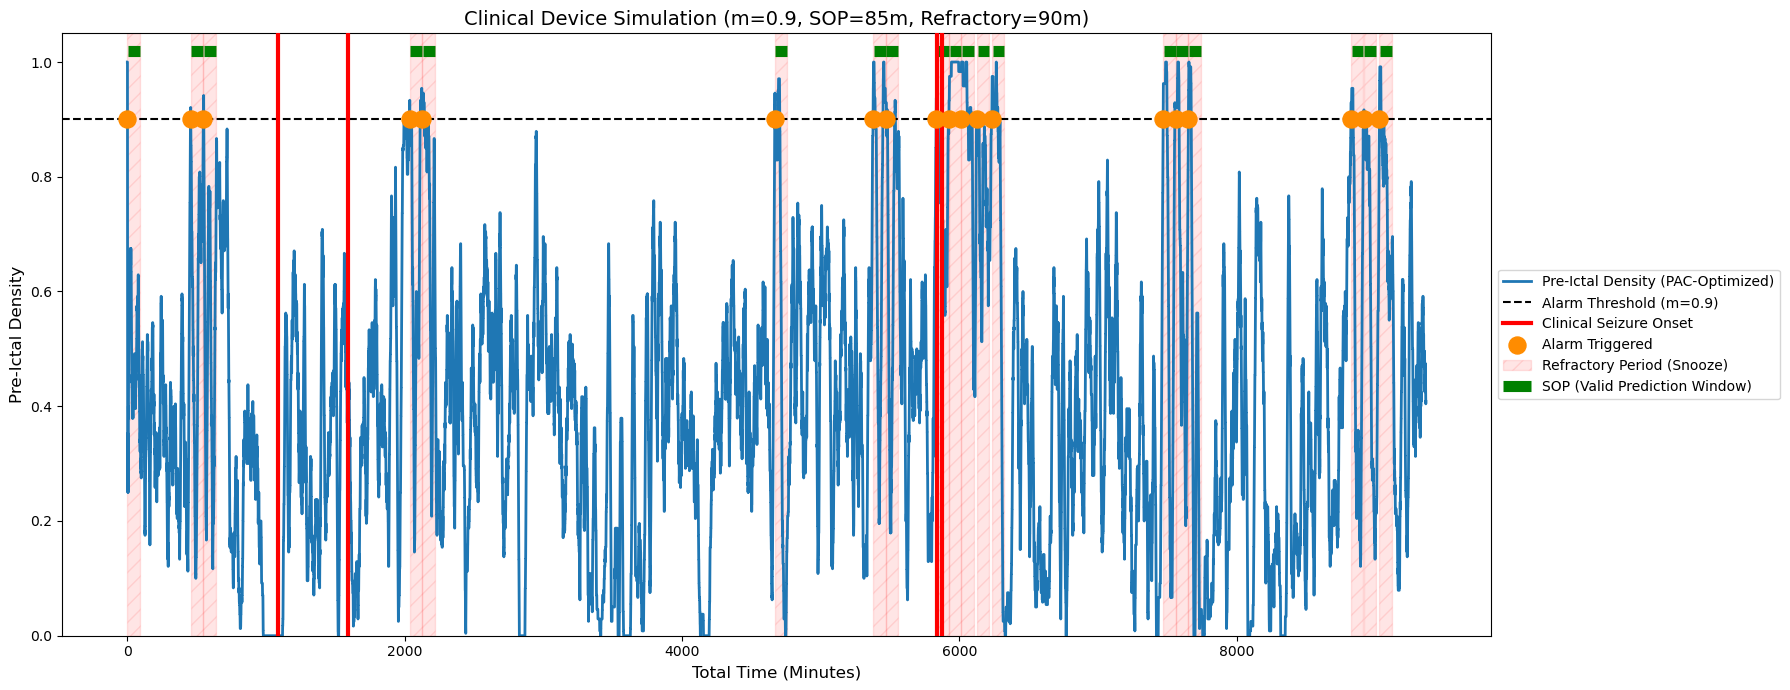

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1. Choose the threshold we want to visualize ---
target_m = 0.90

# --- 2. Re-run the strict device logic for just this threshold ---
alarm_times_sec = []
next_allowed_alarm_sec = 0.0
alarm_indices = np.where(pre_density > target_m)[0]

for idx in alarm_indices:
    current_sec = idx * WINDOW_SEC
    if current_sec >= next_allowed_alarm_sec:
        alarm_times_sec.append(current_sec)
        next_allowed_alarm_sec = current_sec + REFRACTORY_SEC

# --- 3. Plotting ---
plt.figure(figsize=(18, 7))

# Plot the density and threshold line
plt.plot(t_min, pre_density, label="Pre-Ictal Density (PAC-Optimized)", color="#1f77b4", linewidth=2)
plt.axhline(target_m, color="black", linestyle="--", linewidth=1.5, label=f"Alarm Threshold (m={target_m})")

# Track legend entries to avoid duplicates
seen_labels = set()

# Plot Clinical Seizures
for sz_sec in global_seizure_onsets:
    sz_min = sz_sec / 60.0
    label = "Clinical Seizure Onset" if "Clinical Seizure Onset" not in seen_labels else None
    plt.axvline(sz_min, color="red", linewidth=3, zorder=4, label=label)
    seen_labels.add("Clinical Seizure Onset")

# Plot Alarms, SOPs, and Refractory Periods
for alarm_sec in alarm_times_sec:
    alarm_min = alarm_sec / 60.0
    
    # 1. The Alarm Trigger
    label_alarm = "Alarm Triggered" if "Alarm Triggered" not in seen_labels else None
    plt.scatter(alarm_min, target_m, color="darkorange", s=150, zorder=5, label=label_alarm)
    seen_labels.add("Alarm Triggered")
    
    # 2. Refractory Period (Red hatched background)
    ref_end_min = alarm_min + (REFRACTORY_SEC / 60.0)
    label_ref = "Refractory Period (Snooze)" if "Refractory Period (Snooze)" not in seen_labels else None
    plt.axvspan(alarm_min, ref_end_min, color="red", alpha=0.1, hatch='//', label=label_ref)
    seen_labels.add("Refractory Period (Snooze)")
    
    # 3. SOP (Green expected seizure window)
    sop_start_min = alarm_min + (SPH_SEC / 60.0)
    sop_end_min = alarm_min + ((SPH_SEC + SOP_SEC) / 60.0)
    label_sop = "SOP (Valid Prediction Window)" if "SOP (Valid Prediction Window)" not in seen_labels else None
    # Plot as a line block slightly above the graph to keep it clean
    plt.plot([sop_start_min, sop_end_min], [1.02, 1.02], color="green", linewidth=8, solid_capstyle="butt", label=label_sop)
    seen_labels.add("SOP (Valid Prediction Window)")

plt.ylim(0, 1.05)
plt.xlabel("Total Time (Minutes)", fontsize=12)
plt.ylabel("Pre-Ictal Density", fontsize=12)
plt.title(f"Clinical Device Simulation (m={target_m}, SOP={SOP_SEC/60:.0f}m, Refractory={REFRACTORY_SEC/60:.0f}m)", fontsize=14)

# Put legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.tight_layout()
plt.show()

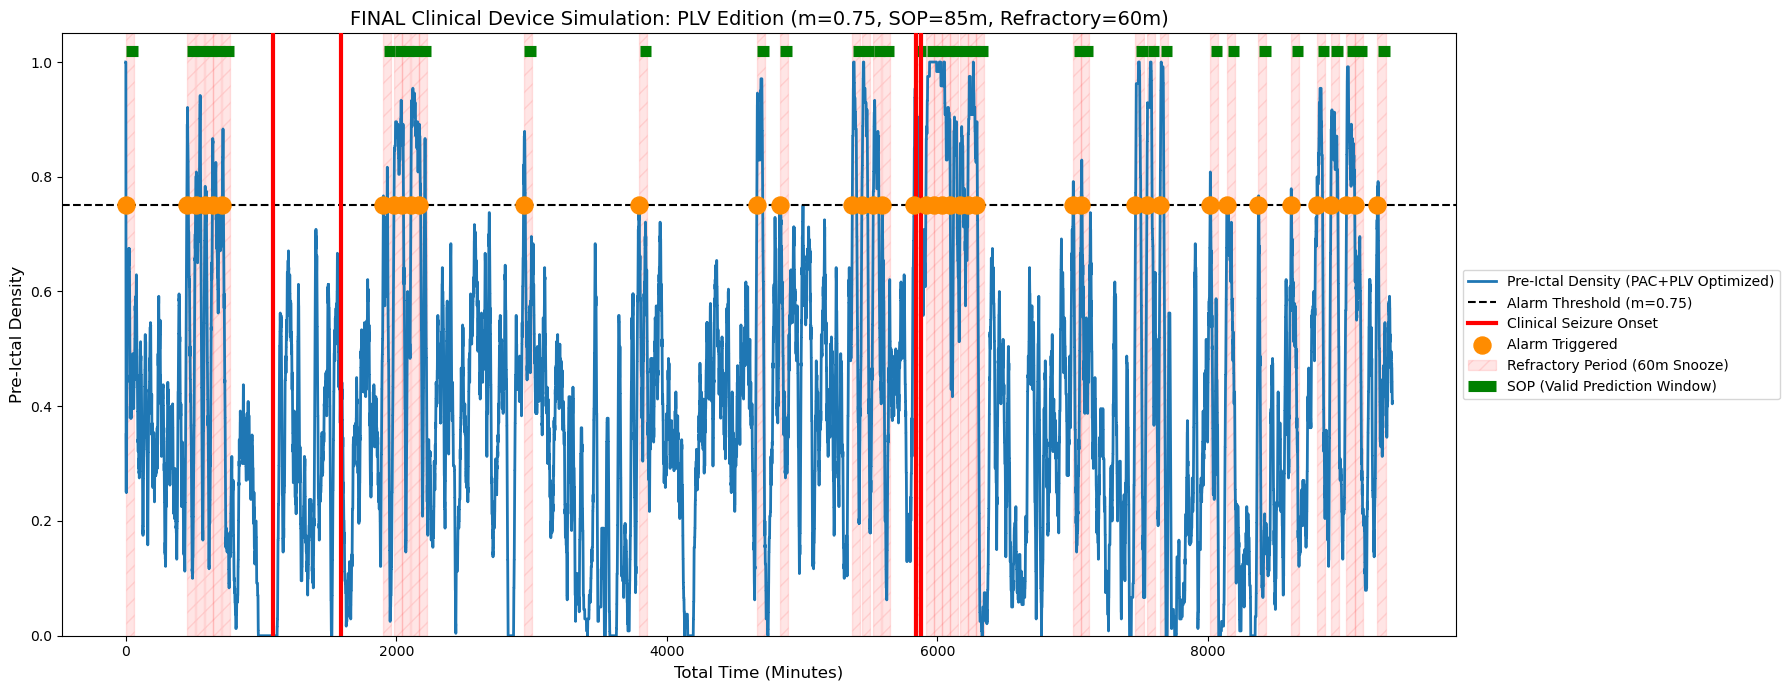

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. The Final PLV Goldilocks Parameters ---
target_m = 0.75
REFRACTORY_SEC = 60 * 60  # 60 minute snooze

# --- 2. Re-run the strict device logic ---
alarm_times_sec = []
next_allowed_alarm_sec = 0.0
alarm_indices = np.where(pre_density > target_m)[0]

for idx in alarm_indices:
    current_sec = idx * WINDOW_SEC
    if current_sec >= next_allowed_alarm_sec:
        alarm_times_sec.append(current_sec)
        next_allowed_alarm_sec = current_sec + REFRACTORY_SEC

# --- 3. Plotting ---
plt.figure(figsize=(18, 7))

# Plot the density and threshold line
plt.plot(t_min, pre_density, label="Pre-Ictal Density (PAC+PLV Optimized)", color="#1f77b4", linewidth=2)
plt.axhline(target_m, color="black", linestyle="--", linewidth=1.5, label=f"Alarm Threshold (m={target_m})")

seen_labels = set()

for sz_sec in global_seizure_onsets:
    sz_min = sz_sec / 60.0
    label = "Clinical Seizure Onset" if "Clinical Seizure Onset" not in seen_labels else None
    plt.axvline(sz_min, color="red", linewidth=3, zorder=4, label=label)
    seen_labels.add("Clinical Seizure Onset")

for alarm_sec in alarm_times_sec:
    alarm_min = alarm_sec / 60.0
    
    label_alarm = "Alarm Triggered" if "Alarm Triggered" not in seen_labels else None
    plt.scatter(alarm_min, target_m, color="darkorange", s=150, zorder=5, label=label_alarm)
    seen_labels.add("Alarm Triggered")
    
    ref_end_min = alarm_min + (REFRACTORY_SEC / 60.0)
    label_ref = f"Refractory Period ({REFRACTORY_SEC//60}m Snooze)" if f"Refractory Period ({REFRACTORY_SEC//60}m Snooze)" not in seen_labels else None
    plt.axvspan(alarm_min, ref_end_min, color="red", alpha=0.1, hatch='//', label=label_ref)
    seen_labels.add(f"Refractory Period ({REFRACTORY_SEC//60}m Snooze)")
    
    sop_start_min = alarm_min + (SPH_SEC / 60.0)
    sop_end_min = alarm_min + ((SPH_SEC + SOP_SEC) / 60.0)
    label_sop = "SOP (Valid Prediction Window)" if "SOP (Valid Prediction Window)" not in seen_labels else None
    plt.plot([sop_start_min, sop_end_min], [1.02, 1.02], color="green", linewidth=8, solid_capstyle="butt", label=label_sop)
    seen_labels.add("SOP (Valid Prediction Window)")

plt.ylim(0, 1.05)
plt.xlabel("Total Time (Minutes)", fontsize=12)
plt.ylabel("Pre-Ictal Density", fontsize=12)
plt.title(f"FINAL Clinical Device Simulation: PLV Edition (m={target_m}, SOP={SOP_SEC/60:.0f}m, Refractory={REFRACTORY_SEC/60:.0f}m)", fontsize=14)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.tight_layout()
plt.show()

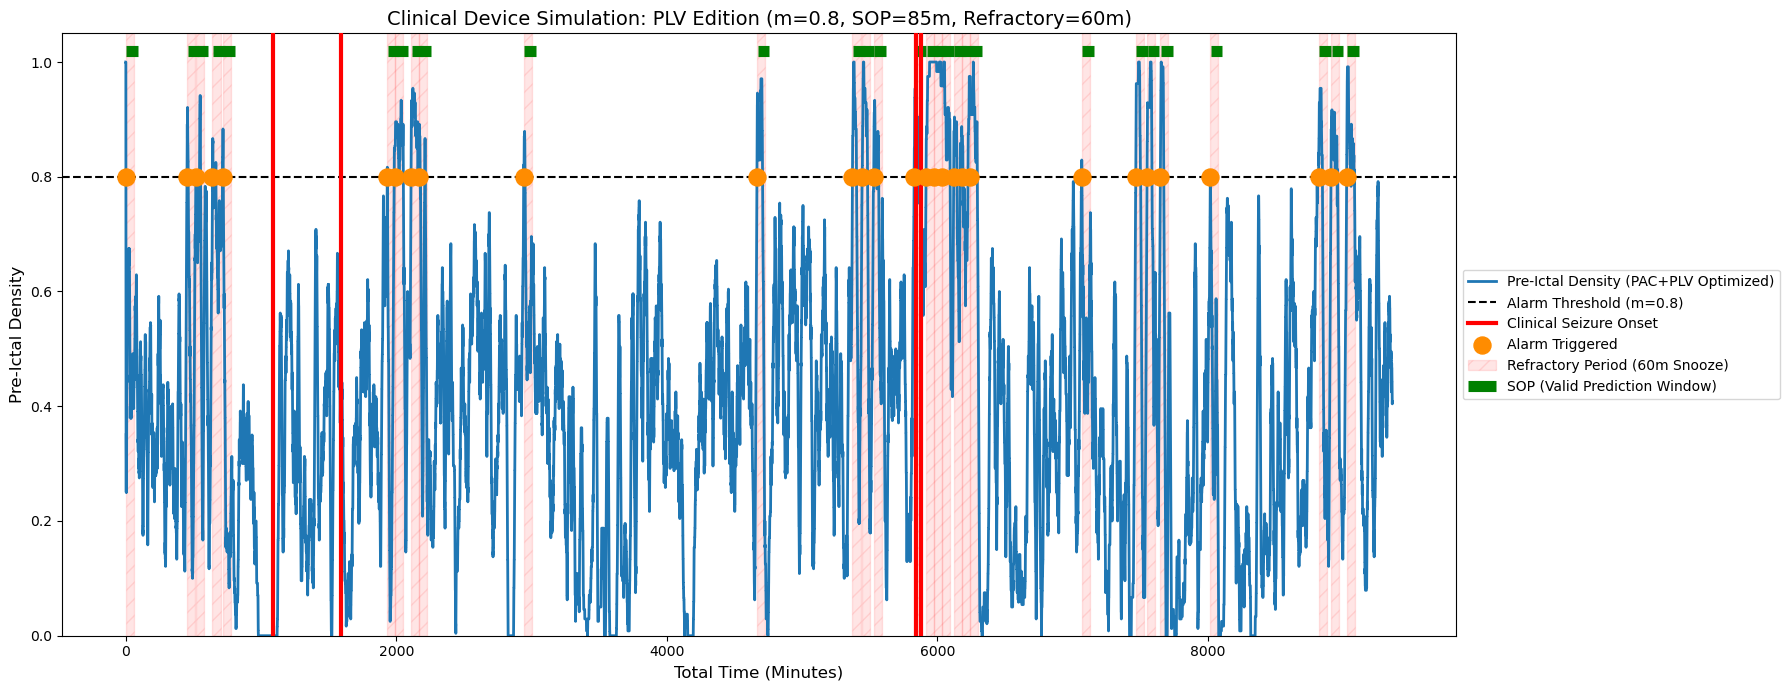

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. The PLV-Optimized Goldilocks Parameters ---
target_m = 0.80
REFRACTORY_SEC = 60 * 60  # Shortened to 60 minutes to prevent shadowing

# --- 2. Re-run the strict device logic for just this threshold ---
alarm_times_sec = []
next_allowed_alarm_sec = 0.0
alarm_indices = np.where(pre_density > target_m)[0]

for idx in alarm_indices:
    current_sec = idx * WINDOW_SEC
    if current_sec >= next_allowed_alarm_sec:
        alarm_times_sec.append(current_sec)
        next_allowed_alarm_sec = current_sec + REFRACTORY_SEC

# --- 3. Plotting ---
plt.figure(figsize=(18, 7))

# Plot the density and threshold line
plt.plot(t_min, pre_density, label="Pre-Ictal Density (PAC+PLV Optimized)", color="#1f77b4", linewidth=2)
plt.axhline(target_m, color="black", linestyle="--", linewidth=1.5, label=f"Alarm Threshold (m={target_m})")

# Track legend entries to avoid duplicates
seen_labels = set()

# Plot Clinical Seizures
for sz_sec in global_seizure_onsets:
    sz_min = sz_sec / 60.0
    label = "Clinical Seizure Onset" if "Clinical Seizure Onset" not in seen_labels else None
    plt.axvline(sz_min, color="red", linewidth=3, zorder=4, label=label)
    seen_labels.add("Clinical Seizure Onset")

# Plot Alarms, SOPs, and Refractory Periods
for alarm_sec in alarm_times_sec:
    alarm_min = alarm_sec / 60.0
    
    # 1. The Alarm Trigger
    label_alarm = "Alarm Triggered" if "Alarm Triggered" not in seen_labels else None
    plt.scatter(alarm_min, target_m, color="darkorange", s=150, zorder=5, label=label_alarm)
    seen_labels.add("Alarm Triggered")
    
    # 2. Refractory Period (Red hatched background)
    ref_end_min = alarm_min + (REFRACTORY_SEC / 60.0)
    label_ref = f"Refractory Period ({REFRACTORY_SEC//60}m Snooze)" if f"Refractory Period ({REFRACTORY_SEC//60}m Snooze)" not in seen_labels else None
    plt.axvspan(alarm_min, ref_end_min, color="red", alpha=0.1, hatch='//', label=label_ref)
    seen_labels.add(f"Refractory Period ({REFRACTORY_SEC//60}m Snooze)")
    
    # 3. SOP (Green expected seizure window)
    sop_start_min = alarm_min + (SPH_SEC / 60.0)
    sop_end_min = alarm_min + ((SPH_SEC + SOP_SEC) / 60.0)
    label_sop = "SOP (Valid Prediction Window)" if "SOP (Valid Prediction Window)" not in seen_labels else None
    plt.plot([sop_start_min, sop_end_min], [1.02, 1.02], color="green", linewidth=8, solid_capstyle="butt", label=label_sop)
    seen_labels.add("SOP (Valid Prediction Window)")

plt.ylim(0, 1.05)
plt.xlabel("Total Time (Minutes)", fontsize=12)
plt.ylabel("Pre-Ictal Density", fontsize=12)
plt.title(f"Clinical Device Simulation: PLV Edition (m={target_m}, SOP={SOP_SEC/60:.0f}m, Refractory={REFRACTORY_SEC/60:.0f}m)", fontsize=14)

# Put legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
plt.tight_layout()
plt.show()